生成数据集

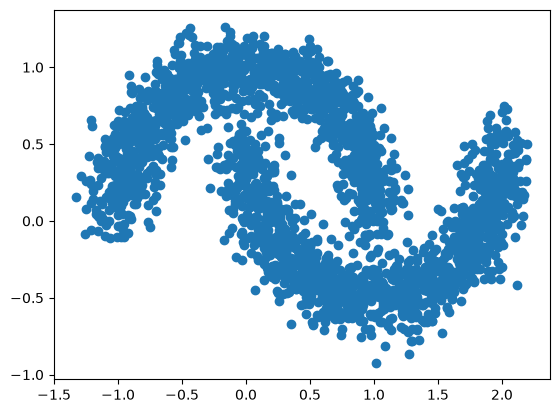

In [1]:
import tensorflow as tf
import tensorflow.linalg
import keras
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import tensorflow_probability as tfp

data_X, data_y = make_moons(n_samples=2500, noise=.125)
del data_y
plt.scatter(x=data_X[:, 0], y=data_X[:, 1], )


定义 MDN 层

In [ ]:
class MDN(keras.Layer):
    def __init__(self, name: str, n_mixture: int, output_dim: int):
        super().__init__(name=name)
        self.n_mixture = n_mixture
        self.output_dim = output_dim

        # 向量 mu， sigma 矩阵对角线向量，p(c = i | x) 向量
        self.n_params = n_mixture * (output_dim*2 + 1)

    def build(self, input_shape):
        super().build(input_shape)
        self.dense = keras.layers.Dense(units=self.n_params)
        self.dense.build(input_shape)

    def call(self, inputs, a):
        return self.dense(input)

    def get_loss(self):
        mdn = self

        class MDNLoss(keras.Loss):
            def call(self, y_true: tf.Tensor, y_pred: tf.Tensor):
                # y_pred shape: (batch_size, n_params)
                mu, sigma_vec, pi = tf.split(y_pred, [mdn.output_dim*2, mdn.output_dim*2, 1], axis=-1)
                sigma_vec = tf.nn.softplus(sigma_vec)

        return MDNLoss(name="MDNLoss")
